<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 01
    </div>
    <div style="font-size: 16px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Phân tích thị trường mỹ phẩm nội vs ngoại trên Tiki"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  PHÂN TÍCH CHUNG & KHÁM PHÁ BỘ DỮ LIỆU TỪ TIKI
</div>

In [32]:
# IMPORT THƯ VIỆN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Xanh dương: hàng trong nước
# Cam: hàng ngoài nước
COLOR_DOMESTIC = '#0062ff'   
COLOR_FOREIGN  = '#ff6b35'   
PALETTE_MAIN   = [COLOR_DOMESTIC, COLOR_FOREIGN]
PALETTE_CAT    = sns.color_palette('tab20', 20)


sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
print('Import thành công!')

Import thành công!


In [33]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **1. GIỚI THIỆU VÀ ĐẶC ĐIỂM DỮ LIỆU**
### **1.1. Tải bộ dữ liệu đã làm sạch**

In [34]:
df = pd.read_csv('tiki_cosmetics_processed.csv')

print('=' * 60)
print('TỔNG QUAN BỘ DỮ LIỆU')
print('=' * 60)
print(f'  • Số sản phẩm (hàng)  : {df.shape[0]:,}')
print(f'  • Số đặc trưng (cột)  : {df.shape[1]}')
print()
print('5 dòng đầu tiên:')
df.head()

TỔNG QUAN BỘ DỮ LIỆU
  • Số sản phẩm (hàng)  : 7,179
  • Số đặc trưng (cột)  : 36

5 dòng đầu tiên:


,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class_corrected,origin_corrected,...,estimated_revenue,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate,is_extreme_outlier
0,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,2461000,True,1,True,0,1,Còn hàng,False,False,False
1,277375219,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,3069000,True,1,True,0,1,Còn hàng,False,False,False
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,932400,True,1,True,0,1,Còn hàng,False,False,False
3,276396782,Sữa rửa mặt X-Men 100g Detox/Sáng da/Ngừa mụn/...,Sữa rửa mặt X-Men Detox/Sáng da/Ngừa mụn/Kiểm ...,X-Men,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,1116000,True,1,True,0,1,Còn hàng,False,False,False
4,276022717,"Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...","Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...",OXY,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,4582000,True,1,True,0,1,Còn hàng,False,False,False


### **1.2. Thống kê kiểu dữ liệu**

BẢNG MÔ TẢ CẤU TRÚC DỮ LIỆU
----------------------------------------------------------------------


Cột,Kiểu dữ liệu,Số giá trị null,Tỉ lệ null (%),Số giá trị duy nhất
product_id,Số nguyên (int64),0,0.00%,"7,179"
name,Chuỗi (object),0,0.00%,"7,099"
name_clean,Chuỗi (object),0,0.00%,"6,947"
brand_name,Chuỗi (object),0,0.00%,956
seller_name,Chuỗi (object),0,0.00%,489
product_type,Chuỗi (object),0,0.00%,5
category,Chuỗi (object),0,0.00%,30
primary_category,Chuỗi (object),0,0.00%,110
origin_class_corrected,Chuỗi (object),0,0.00%,2
origin_corrected,Chuỗi (object),0,0.00%,36


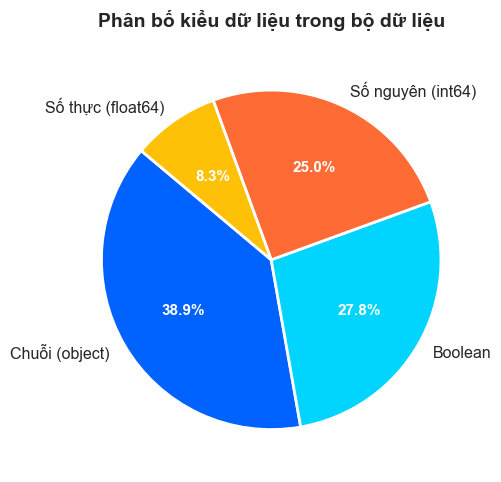

BẢNG TÓM TẮT CẤU TRÚC DỮ LIỆU
----------------------------------------------------------------------


Chỉ số thống kê,Giá trị
Tổng số dòng dữ liệu (Số quan sát),"7,179 dòng"
Tổng số cột dữ liệu (Số biến),36 cột
Số cột kiểu: Số nguyên (int64),9 cột
Số cột kiểu: Số thực (float64),3 cột
Số cột kiểu: Chuỗi (object),14 cột
Số cột kiểu: Boolean,10 cột
Số cột có chứa giá trị Null,0 / 36 cột
Tổng số ô dữ liệu bị thiếu,0 ô


In [35]:
# 1.2 THỐNG KÊ KIỂU DỮ LIỆU
import pandas as pd
import matplotlib.pyplot as plt

# Các kiểu dữ liệu
dtype_map = {
    'int64': 'Số nguyên (int64)',
    'float64': 'Số thực (float64)',
    'object': 'Chuỗi (object)',
    'bool': 'Boolean',
}
dtype_df = pd.DataFrame({
    'Cột': df.columns,
    'Kiểu dữ liệu': [dtype_map.get(str(t), str(t)) for t in df.dtypes],
    'Số giá trị null': df.isnull().sum().values,
    'Tỉ lệ null (%)': (df.isnull().mean() * 100).round(2).values,
    'Số giá trị duy nhất': [df[c].nunique() for c in df.columns]
})

print('BẢNG MÔ TẢ CẤU TRÚC DỮ LIỆU')
print('-' * 70)

#format cho bảng
styled_table = (dtype_df.style
    .hide(axis="index")
    .format({
        'Tỉ lệ null (%)': '{:.2f}%',
        'Số giá trị null': '{:,}',
        'Số giá trị duy nhất': '{:,}'
    })
    .set_properties(**{
        'background-color': '#ffffff',  
        'color': '#333333',             
        'border': '1px solid #e0e0e0',  
        'text-align': 'center',
        'padding': '10px'
    })
    
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#0062ff !important'), 
                   ('color', 'white !important'),
                   ('font-weight', 'bold !important'), 
                   ('text-align', 'center !important'),
                   ('border', '1px solid #e0e0e0 !important'),
                   ('padding', '12px !important')]},
                   
        {'selector': 'tr:hover td',
         'props': [('background-color', '#f1f8ff !important')]}
    ])
)
display(styled_table)

# --- Biểu đồ tròn phân bố kiểu dữ liệu ---
type_counts = df.dtypes.astype(str).value_counts()
labels = [dtype_map.get(t, t) for t in type_counts.index]
colors = ['#0062ff', '#00d4ff', '#ff6b35', '#ffc107', '#6c757d']

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors[:len(type_counts)],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_color('white')
    at.set_fontweight('bold')
ax.set_title('Phân bố kiểu dữ liệu trong bộ dữ liệu', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# THỐNG KÊ CẤU TRÚC DỮ LIỆU TỔNG QUAN

# 1. Gom tất cả dữ liệu vào một danh sách (list)
summary_data = [
    ('Tổng số dòng dữ liệu (Số quan sát)', f"{df.shape[0]:,} dòng"),
    ('Tổng số cột dữ liệu (Số biến)', f"{df.shape[1]} cột")
]

# Đếm số cột theo kiểu dữ liệu
for t_raw, label in dtype_map.items():
    count = (df.dtypes.astype(str) == t_raw).sum()
    if count > 0:
        summary_data.append((f'Số cột kiểu: {label}', f"{count} cột"))

# Đếm dữ liệu thiếu (Null)
null_cols = (df.isnull().sum() > 0).sum()
total_nulls = df.isnull().sum().sum()
summary_data.append(('Số cột có chứa giá trị Null', f"{null_cols} / {df.shape[1]} cột"))
summary_data.append(('Tổng số ô dữ liệu bị thiếu', f"{total_nulls:,} ô"))

# 2. Chuyển thành DataFrame
quick_stat_df = pd.DataFrame(summary_data, columns=['Chỉ số thống kê', 'Giá trị'])

print('BẢNG TÓM TẮT CẤU TRÚC DỮ LIỆU')
print('-' * 70)

# 3. Format giao diện đồng bộ
styled_quick_stat = (quick_stat_df.style
    .hide(axis="index")
    .set_properties(**{
        'background-color': '#ffffff',  
        'color': '#333333',             
        'border': '1px solid #e0e0e0',  
        'text-align': 'left',      
        'padding': '12px 25px'
    })
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#0062ff !important'), 
                   ('color', 'white !important'),
                   ('font-weight', 'bold !important'), 
                   ('text-align', 'center !important'),
                   ('border', '1px solid #e0e0e0 !important'),
                   ('padding', '12px !important')]},
        {'selector': 'tr:hover td',
         'props': [('background-color', '#f1f8ff !important')]}
    ])
)

display(styled_quick_stat)

In [ ]:
# THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ

num_cols = ['price', 'original_price', 'discount_rate', 'sold_count',
            'review_count', 'review_ratio', 'rating', 'estimated_revenue']

# Tạo bảng describe và chuyển vị (Transpose)
desc = df[num_cols].describe().T
desc.columns = ['Số quan sát', 'Trung bình', 'Độ lệch chuẩn',
                'Min', 'Q1 (25%)', 'Trung vị (50%)', 'Q3 (75%)', 'Max']

# Kéo tên các biến từ Index ra thành 1 cột bình thường tên là "Biến số"
desc = desc.reset_index()
desc.rename(columns={'index': 'Biến số'}, inplace=True)

print('THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ')
print('-' * 70)

# --- PHẦN STYLE BẢNG
styled_desc = (desc.style
    .hide(axis="index")
    .format({
        'Số quan sát': '{:,.0f}', 
        'Trung bình': '{:,.2f}',
        'Độ lệch chuẩn': '{:,.2f}',
        'Min': '{:,.2f}',
        'Q1 (25%)': '{:,.2f}',
        'Trung vị (50%)': '{:,.2f}',
        'Q3 (75%)': '{:,.2f}',
        'Max': '{:,.2f}'
    })
    .set_properties(**{
        'background-color': '#ffffff',  
        'color': '#333333',             
        'border': '1px solid #e0e0e0',  
        'text-align': 'center',
        'padding': '10px'
    })
    
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#0062ff !important'), 
                   ('color', 'white !important'),
                   ('font-weight', 'bold !important'), 
                   ('text-align', 'center !important'),
                   ('border', '1px solid #e0e0e0 !important'),
                   ('padding', '12px !important')]},
                   
        # Rê chuột vào dòng nào, dòng đó sáng lên
        {'selector': 'tr:hover td',
         'props': [('background-color', '#f1f8ff !important')]}
    ])
)

display(styled_desc)

THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ
----------------------------------------------------------------------


Biến số,Số quan sát,Trung bình,Độ lệch chuẩn,Min,Q1 (25%),Trung vị (50%),Q3 (75%),Max
price,"7,179","639,649.50","987,774.61","10,000.00","175,875.00","319,000.00","650,000.00","18,000,000.00"
original_price,"7,179","688,097.94","1,045,243.58","10,000.00","195,500.00","365,000.00","710,000.00","18,000,000.00"
discount_rate,"7,179",7.78,15.01,0.00,0.00,0.00,7.00,73.00
sold_count,"7,179",623.71,"9,026.97",0.00,0.00,1.00,9.00,"553,516.00"
review_count,"7,179",8.00,58.10,0.00,0.00,0.00,1.00,"1,652.00"
review_ratio,"7,179",0.09,0.27,0.00,0.00,0.00,0.11,14.00
rating,"7,179",1.60,2.24,0.00,0.00,0.00,4.60,5.00
estimated_revenue,"7,179","64,589,756.64","731,357,193.98",0.00,0.00,"342,000.00","3,106,500.00","43,727,764,000.00"


## **2. PHÂN TÍCH ĐƠN BIẾN - DIỆN MẠO THỊ TRƯỜNG**
### **2.1. Phân bố các nhóm ngành hàng**

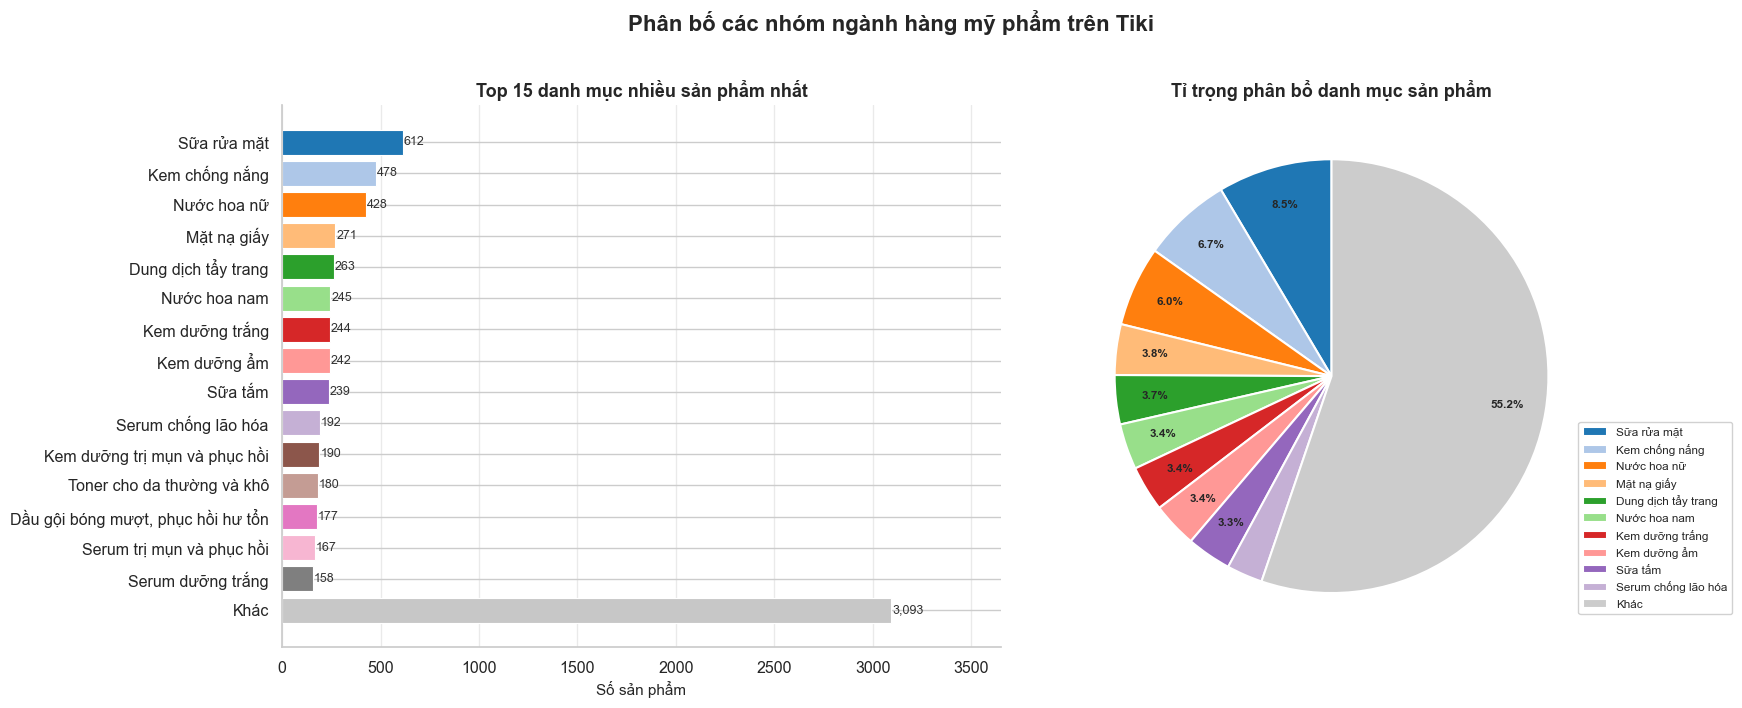

NHẬN XÉT:
  • Tổng cộng 110 danh mục sản phẩm.
  • Top 3 danh mục chiếm nhiều sản phẩm nhất:
    1. Sữa rửa mặt: 612 sản phẩm (8.5%)
    2. Kem chống nắng: 478 sản phẩm (6.7%)
    3. Nước hoa nữ: 428 sản phẩm (6.0%)
  • Top 10 danh mục chiếm 44.8% tổng sản phẩm.


In [37]:
# 2.1 PHÂN BỐ CÁC NHÓM NGÀNH HÀNG
cat_counts = df['primary_category'].value_counts()
top_n = 15
top_cats = cat_counts.head(top_n)
other_count = cat_counts.iloc[top_n:].sum()
if other_count > 0:
    top_cats['Khác'] = other_count

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Phân bố các nhóm ngành hàng mỹ phẩm trên Tiki',
             fontsize=16, fontweight='bold', y=1.01)

# --- Bar chart ---
ax1 = axes[0]
colors_bar = [PALETTE_CAT[i % 20] for i in range(len(top_cats))]
bars = ax1.barh(top_cats.index[::-1], top_cats.values[::-1],
                color=colors_bar[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, top_cats.values[::-1]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', ha='left', fontsize=9, color='#333')
ax1.set_xlabel('Số sản phẩm', fontsize=11)
ax1.set_title(f'Top {top_n} danh mục nhiều sản phẩm nhất', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_xlim(0, top_cats.max() * 1.18)

# --- Pie chart top 10
ax2 = axes[1]
pie_data = cat_counts.head(10)
pie_other = cat_counts.iloc[10:].sum()
pie_labels = list(pie_data.index) + ['Khác']
pie_vals = list(pie_data.values) + [pie_other]
pie_colors = list(PALETTE_CAT[:10]) + ['#cccccc']

wedges, _, autotexts = ax2.pie(
    pie_vals,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    colors=pie_colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight('bold')
ax2.legend(wedges, pie_labels, loc='lower right', fontsize=8.5,
           bbox_to_anchor=(1.25, 0.05), framealpha=0.9)
ax2.set_title('Tỉ trọng phân bổ danh mục sản phẩm', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_2_1_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Nhận xét ---
print('NHẬN XÉT:')
print(f'  • Tổng cộng {df["primary_category"].nunique()} danh mục sản phẩm.')
print(f'  • Top 3 danh mục chiếm nhiều sản phẩm nhất:')
for i, (cat, cnt) in enumerate(cat_counts.head(3).items(), 1):
    print(f'    {i}. {cat}: {cnt:,} sản phẩm ({cnt/len(df)*100:.1f}%)')
top10_pct = cat_counts.head(10).sum() / len(df) * 100
print(f'  • Top 10 danh mục chiếm {top10_pct:.1f}% tổng sản phẩm.')

### **2.2. Thị phần hàng Trong nước vs Ngoài nước**

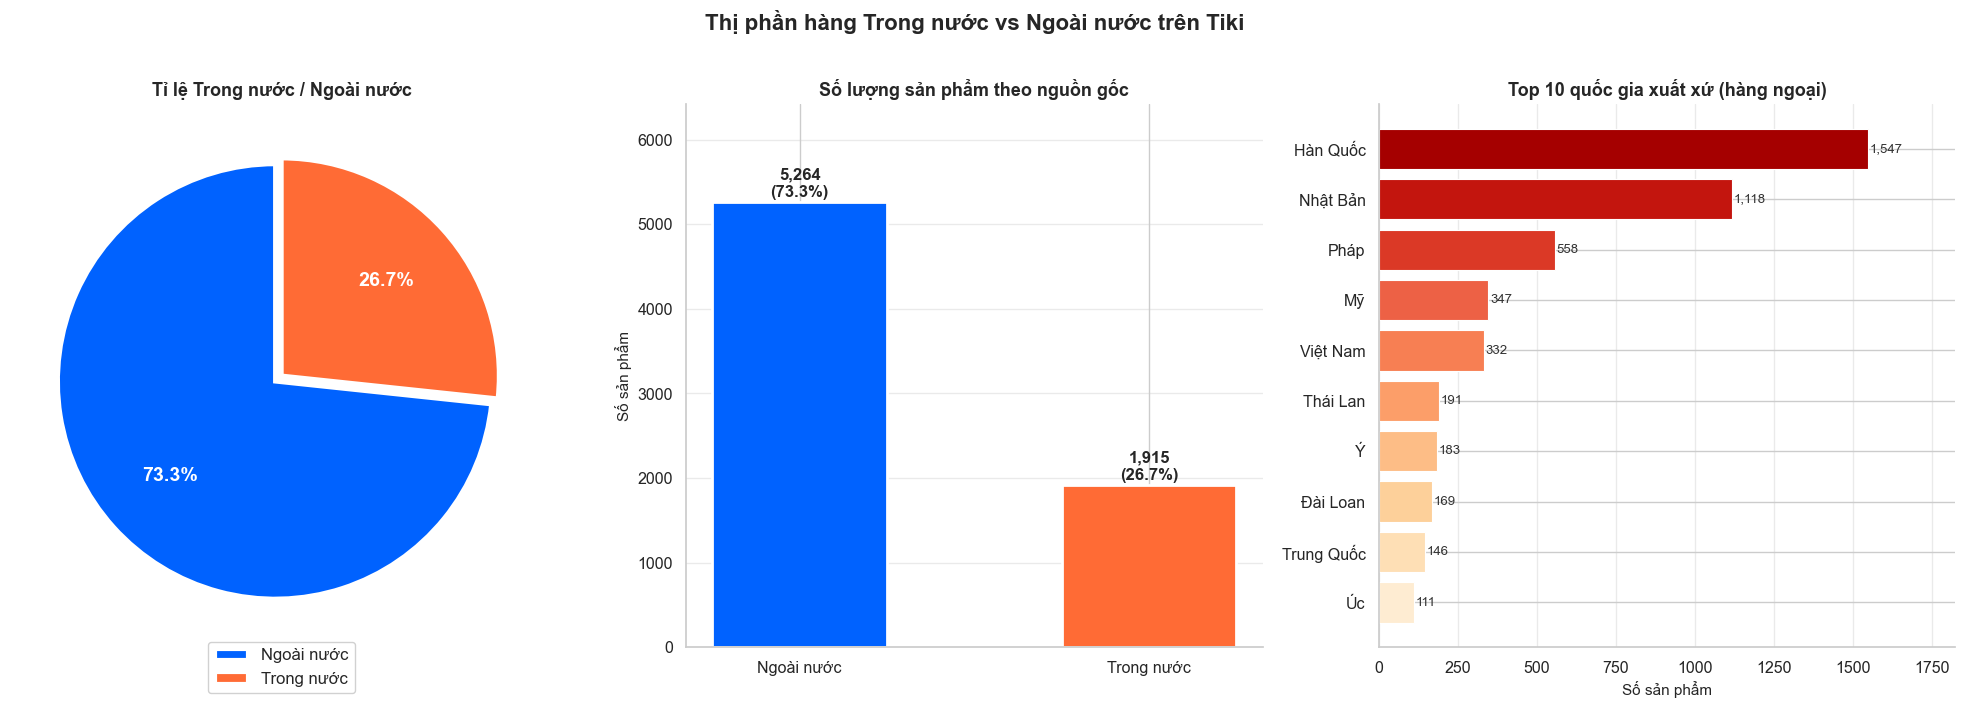

NHẬN XÉT:
  • Hàng Ngoài nước chiếm đa số: 73.3% (5,264 SP).
  • Hàng Trong nước (Việt Nam): 26.7% (1,915 SP).
  • Hàn Quốc dẫn đầu hàng ngoại với 1,547 sản phẩm.


In [38]:

# 2.2 THỊ PHẦN HÀNG TRONG NƯỚC vs NGOÀI NƯỚC

# --- Phân loại Trong nước / Ngoài nước ---
df['origin_group'] = df['is_imported_corrected'].map(
    {False: 'Trong nước', True: 'Ngoài nước'}
)

origin_counts = df['origin_group'].value_counts()
domestic_pct = origin_counts.get('Trong nước', 0) / len(df) * 100
foreign_pct  = origin_counts.get('Ngoài nước', 0) / len(df) * 100

# --- Top quốc gia Ngoài nước ---
foreign_countries = (
    df[df['is_imported_corrected'] == True]['origin_normalized']
    .value_counts().head(10)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Thị phần hàng Trong nước vs Ngoài nước trên Tiki',
             fontsize=16, fontweight='bold', y=1.01)

# --- Pie chart tổng quan ---
ax1 = axes[0]
wedges, _, autotexts = ax1.pie(
    origin_counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=PALETTE_MAIN,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=3),
    explode=[0.04, 0],
    pctdistance=0.65
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')
    at.set_color('white')
ax1.legend(wedges, origin_counts.index, loc='lower center',
           bbox_to_anchor=(0.5, -0.1), fontsize=12, framealpha=0.9)
ax1.set_title('Tỉ lệ Trong nước / Ngoài nước', fontsize=13, fontweight='bold')

# --- Bar chart số lượng ---
ax2 = axes[1]
bars = ax2.bar(origin_counts.index, origin_counts.values,
               color=PALETTE_MAIN, edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, origin_counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Số sản phẩm', fontsize=11)
ax2.set_title('Số lượng sản phẩm theo nguồn gốc', fontsize=13, fontweight='bold')
ax2.set_ylim(0, origin_counts.max() * 1.22)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.4)

# --- Top quốc gia nhập khẩu ---
ax3 = axes[2]
colors_country = sns.color_palette('OrRd_r', len(foreign_countries))
bars3 = ax3.barh(foreign_countries.index[::-1], foreign_countries.values[::-1],
                 color=colors_country[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars3, foreign_countries.values[::-1]):
    ax3.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9.5, color='#333')
ax3.set_xlabel('Số sản phẩm', fontsize=11)
ax3.set_title('Top 10 quốc gia xuất xứ (hàng ngoại)', fontsize=13, fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(axis='x', alpha=0.4)
ax3.set_xlim(0, foreign_countries.max() * 1.18)

plt.tight_layout()
plt.savefig('plot_2_2_origin_share.png', dpi=150, bbox_inches='tight')
plt.show()

print('NHẬN XÉT:')
print(f'  • Hàng Ngoài nước chiếm đa số: {foreign_pct:.1f}% ({origin_counts.get("Ngoài nước", 0):,} SP).')
print(f'  • Hàng Trong nước (Việt Nam): {domestic_pct:.1f}% ({origin_counts.get("Trong nước", 0):,} SP).')
print(f'  • Hàn Quốc dẫn đầu hàng ngoại với {foreign_countries.iloc[0]:,} sản phẩm.')

### **2.3. Tổng quan về giá bán**

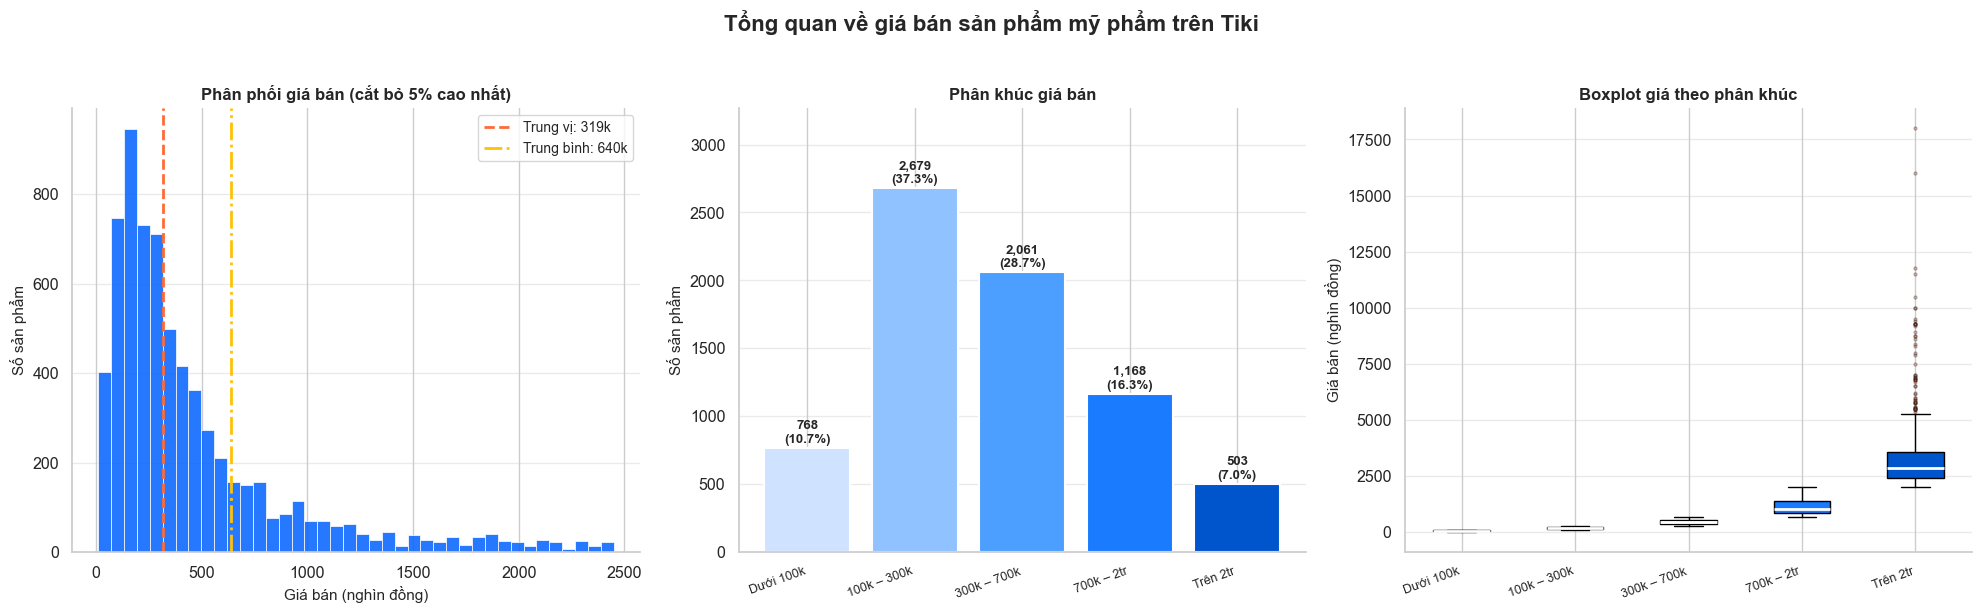

BẢNG TÓM TẮT THÔNG SỐ GIÁ CẢ
----------------------------------------------------------------------


Chỉ số giá bán,Giá trị
Giá thấp nhất (Min),10.0k
Giá cao nhất (Max),"18,000.0k"
Giá trung vị (Median),319.0k
Giá trung bình (Mean),639.6k
Mốc 25% (Q1),175.9k
Mốc 75% (Q3),650.0k
Phân khúc phổ biến nhất,"100k – 300k (2,679 SP)"


In [ ]:

# 2.3 TỔNG QUAN VỀ GIÁ BÁN


price_k = df['price'] / 1000   

# Thứ tự phân khúc giá
seg_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
seg_counts = df['price_segment'].value_counts().reindex(seg_order)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Tổng quan về giá bán sản phẩm mỹ phẩm trên Tiki',
             fontsize=16, fontweight='bold', y=1.02)

ax1 = axes[0]
p95 = price_k.quantile(0.95)
price_trim = price_k[price_k <= p95]
ax1.hist(price_trim, bins=40, color='#0062ff', edgecolor='white',
         linewidth=0.6, alpha=0.85)
ax1.axvline(price_k.median(), color='#ff6b35', lw=2, linestyle='--',
            label=f'Trung vị: {price_k.median():,.0f}k')
ax1.axvline(price_k.mean(), color='#ffc107', lw=2, linestyle='-.',
            label=f'Trung bình: {price_k.mean():,.0f}k')
ax1.set_xlabel('Giá bán (nghìn đồng)', fontsize=11)
ax1.set_ylabel('Số sản phẩm', fontsize=11)
ax1.set_title('Phân phối giá bán (cắt bỏ 5% cao nhất)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.4)

# --- Bar chart phân khúc giá ---
ax2 = axes[1]
seg_colors = ['#cfe2ff', '#90c2ff', '#4d9fff', '#1a7bff', '#0055cc']
bars = ax2.bar(seg_order, seg_counts.values, color=seg_colors,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, seg_counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9.5, fontweight='bold')
ax2.set_ylabel('Số sản phẩm', fontsize=11)
ax2.set_title('Phân khúc giá bán', fontsize=12, fontweight='bold')
ax2.set_ylim(0, seg_counts.max() * 1.22)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.4)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=9)

# --- Boxplot giá theo phân khúc ---
ax3 = axes[2]
data_by_seg = [price_k[df['price_segment'] == s].values for s in seg_order]
bp = ax3.boxplot(data_by_seg, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3,
                                 markerfacecolor='#ff6b35'))
for patch, color in zip(bp['boxes'], seg_colors):
    patch.set_facecolor(color)
ax3.set_xticklabels(seg_order, rotation=20, ha='right', fontsize=9)
ax3.set_ylabel('Giá bán (nghìn đồng)', fontsize=11)
ax3.set_title('Boxplot giá theo phân khúc', fontsize=12, fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_2_3_price_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Thống kê bổ sung ---

# 1. Tạo danh sách dữ liệu thống kê
price_stats_data = [
    ('Giá thấp nhất (Min)', f"{price_k.min():,.1f}k"),
    ('Giá cao nhất (Max)', f"{price_k.max():,.1f}k"),
    ('Giá trung vị (Median)', f"{price_k.median():,.1f}k"),
    ('Giá trung bình (Mean)', f"{price_k.mean():,.1f}k"),
    ('Mốc 25% (Q1)', f"{price_k.quantile(0.25):,.1f}k"),
    ('Mốc 75% (Q3)', f"{price_k.quantile(0.75):,.1f}k"),
    ('Phân khúc phổ biến nhất', f"{seg_counts.idxmax()} ({seg_counts.max():,} SP)")
]

# 2. Chuyển thành DataFrame
price_stats_df = pd.DataFrame(price_stats_data, columns=['Chỉ số giá bán', 'Giá trị'])

print('BẢNG TÓM TẮT THÔNG SỐ GIÁ CẢ')
print('-' * 70)

# 3. Format giao diện
styled_price_stats = (price_stats_df.style
    .hide(axis="index")
    .set_properties(**{
        'background-color': '#ffffff',  
        'color': '#333333',             
        'border': '1px solid #e0e0e0',  
        'text-align': 'left',      
        'padding': '12px 25px'
    })
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#0062ff !important'), 
                   ('color', 'white !important'),
                   ('font-weight', 'bold !important'), 
                   ('text-align', 'center !important'),
                   ('border', '1px solid #e0e0e0 !important'),
                   ('padding', '12px !important')]},
        {'selector': 'tr:hover td',
         'props': [('background-color', '#f1f8ff !important')]}
    ])
)

display(styled_price_stats)

### **2.4. Thống kê về lượt bán và đánh giá**

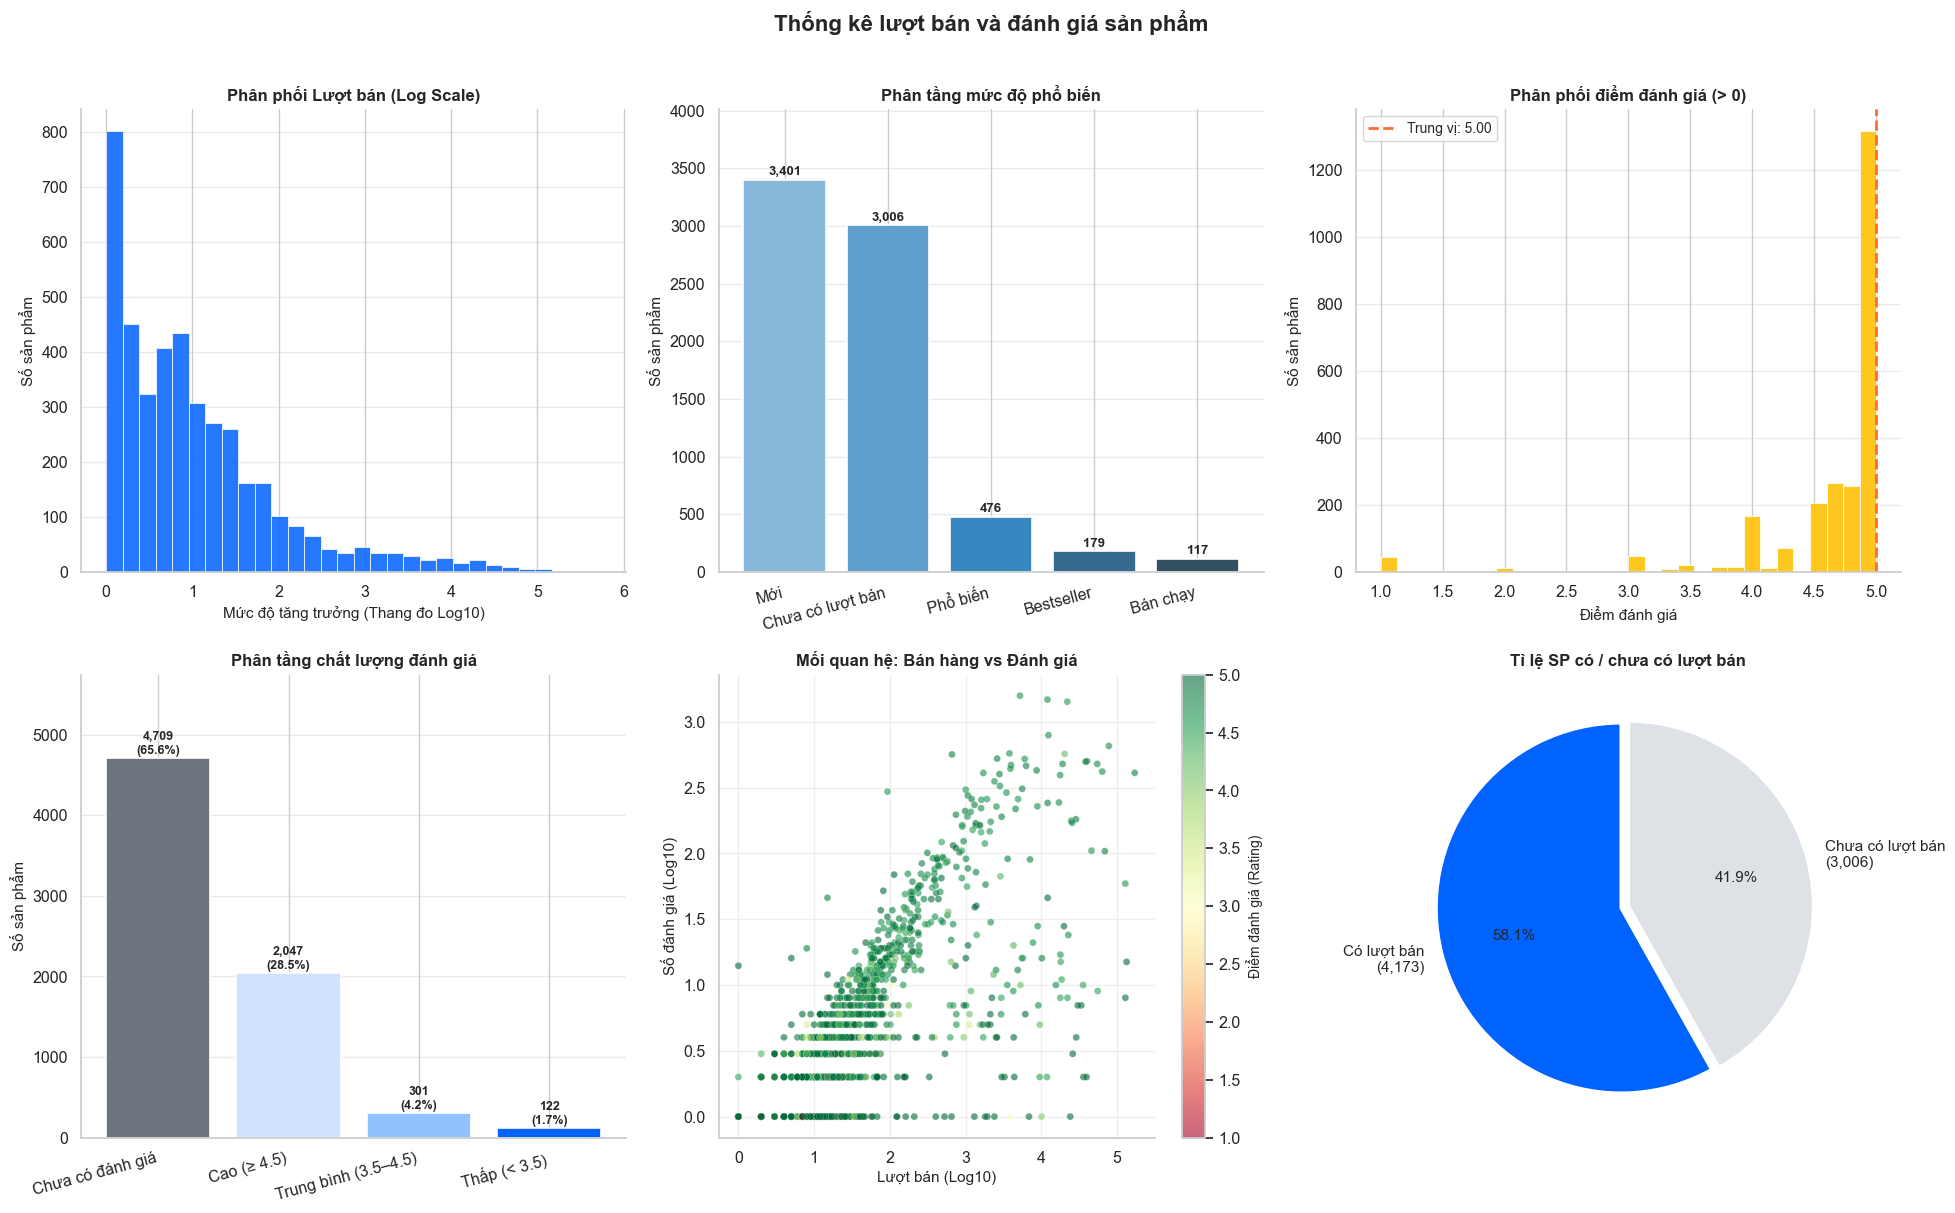

BẢNG TÓM TẮT HIỆU SUẤT BÁN HÀNG VÀ ĐÁNH GIÁ
---------------------------------------------------------------------------


Chỉ số kinh doanh & Uy tín,Giá trị
Sản phẩm chưa có lượt bán,"3,006 SP (41.9%)"
Lượt bán trung bình,623.7 lượt
Lượt bán trung vị,1 lượt
Sản phẩm có lượt bán khủng (> 1000),235 SP (3.3%)
Sản phẩm đã được đánh giá (Rating > 0),"2,470 SP (34.4%)"
Điểm Rating trung bình (chỉ tính SP có đánh giá),4.64 / 5 sao


In [48]:
# 2.4 THỐNG KÊ VỀ LƯỢT BÁN VÀ ĐÁNH GIÁ

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Thống kê lượt bán và đánh giá sản phẩm', fontsize=16, fontweight='bold', y=1.01)

# --- 2.4.1 Phân phối lượt bán (log scale) ---
ax = axes[0][0]
sold_pos = df['sold_count'][df['sold_count'] > 0]
# Sử dụng log10 để thu hẹp khoảng cách giữa các giá trị cực lớn
ax.hist(np.log10(sold_pos), bins=30, color='#0062ff',
        edgecolor='white', linewidth=0.6, alpha=0.85)

# Đổi label trục X cho dễ hiểu hơn
ax.set_xlabel('Mức độ tăng trưởng (Thang đo Log10)', fontsize=11)
ax.set_ylabel('Số sản phẩm', fontsize=11)
ax.set_title('Phân phối Lượt bán (Log Scale)', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)

# --- 2.4.2 Popularity Tier ---
ax = axes[0][1]
tier_order = df['popularity_tier'].value_counts().index.tolist()
tier_counts = df['popularity_tier'].value_counts().reindex(tier_order)
tier_colors = sns.color_palette('Blues_d', len(tier_counts))
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=tier_colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{val:,}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
ax.set_ylabel('Số sản phẩm', fontsize=11)
ax.set_title('Phân tầng mức độ phổ biến', fontsize=12, fontweight='bold')
ax.set_ylim(0, tier_counts.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

# --- 2.4.3 Phân phối rating ---
ax = axes[0][2]
rating_nz = df['rating'][df['rating'] > 0]
ax.hist(rating_nz, bins=30, color='#ffc107', edgecolor='white',
        linewidth=0.6, alpha=0.9)
ax.axvline(rating_nz.median(), color='#ff6b35', lw=2, linestyle='--',
           label=f'Trung vị: {rating_nz.median():.2f}')
ax.set_xlabel('Điểm đánh giá', fontsize=11)
ax.set_ylabel('Số sản phẩm', fontsize=11)
ax.set_title('Phân phối điểm đánh giá (> 0)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)

# --- 2.4.4 Rating Tier ---
ax = axes[1][0]
rt_counts = df['rating_tier'].value_counts()
rt_colors = ['#6c757d', '#cfe2ff', '#90c2ff', '#0062ff', '#003d99']
bars = ax.bar(rt_counts.index, rt_counts.values,
              color=rt_colors[:len(rt_counts)], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, rt_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Số sản phẩm', fontsize=11)
ax.set_title('Phân tầng chất lượng đánh giá', fontsize=12, fontweight='bold')
ax.set_ylim(0, rt_counts.max() * 1.22)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

# --- 2.4.5 Scatter Lượt bán vs Review (Cực kỳ trực quan) ---
ax = axes[1][1]
# Lọc mẫu 1500 dòng để scatter không bị dính chùm quá mức
sample = df[(df['sold_count'] > 0) & (df['review_count'] > 0)].sample(
    min(1500, len(df)), random_state=42
)
sc = ax.scatter(
    np.log10(sample['sold_count']), 
    np.log10(sample['review_count']), 
    c=sample['rating'], cmap='RdYlGn', alpha=0.6, s=25, edgecolor='w', linewidth=0.2
)
# Thêm thanh màu để biết chấm nào là 5 sao (xanh), chấm nào 1 sao (đỏ)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Điểm đánh giá (Rating)', fontsize=10)

ax.set_xlabel('Lượt bán (Log10)', fontsize=11)
ax.set_ylabel('Số đánh giá (Log10)', fontsize=11)
ax.set_title('Mối quan hệ: Bán hàng vs Đánh giá', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)

# --- 2.4.6 Tỉ lệ sản phẩm có lượt bán = 0 ---
ax = axes[1][2]
zero_sold = (df['sold_count'] == 0).sum()
nonzero_sold = (df['sold_count'] > 0).sum()
ax.pie([nonzero_sold, zero_sold],
       labels=[f'Có lượt bán\n({nonzero_sold:,})', f'Chưa có lượt bán\n({zero_sold:,})'],
       autopct='%1.1f%%',
       colors=['#0062ff', '#dee2e6'],
       startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2.5),
       explode=[0.04, 0],
       textprops={'fontsize': 11})
ax.set_title('Tỉ lệ SP có / chưa có lượt bán', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_2_4_sales_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

# THỐNG KÊ CHI TIẾT LƯỢT BÁN VÀ ĐÁNH GIÁ

# 1. Tính toán các chỉ số
total_rows = len(df)
zero_sold_count = (df['sold_count'] == 0).sum()
high_sold_count = (df['sold_count'] > 1000).sum()
rated_count = (df['rating'] > 0).sum()
avg_rating_above_zero = df[df['rating'] > 0]['rating'].mean()

# 2. Gom dữ liệu vào danh sách
sales_rating_data = [
    ('Sản phẩm chưa có lượt bán', f"{zero_sold_count:,} SP ({zero_sold_count/total_rows*100:.1f}%)"),
    ('Lượt bán trung bình', f"{df['sold_count'].mean():,.1f} lượt"),
    ('Lượt bán trung vị', f"{df['sold_count'].median():,.0f} lượt"),
    ('Sản phẩm có lượt bán khủng (> 1000)', f"{high_sold_count:,} SP ({high_sold_count/total_rows*100:.1f}%)"),
    ('Sản phẩm đã được đánh giá (Rating > 0)', f"{rated_count:,} SP ({rated_count/total_rows*100:.1f}%)"),
    ('Điểm Rating trung bình (chỉ tính SP có đánh giá)', f"{avg_rating_above_zero:.2f} / 5 sao")
]

# 3. Tạo DataFrame
sales_rating_df = pd.DataFrame(sales_rating_data, columns=['Chỉ số kinh doanh & Uy tín', 'Giá trị'])

print('BẢNG TÓM TẮT HIỆU SUẤT BÁN HÀNG VÀ ĐÁNH GIÁ')
print('-' * 75)

# 4. Format giao diện đồng bộ
styled_sales_rating = (sales_rating_df.style
    .hide(axis="index")
    .set_properties(**{
        'background-color': '#ffffff',  
        'color': '#333333',             
        'border': '1px solid #e0e0e0',  
        'text-align': 'left',      
        'padding': '12px 25px'
    })
    .set_table_styles([
        # Header xanh biển đặc trưng
        {'selector': 'th',
         'props': [('background-color', '#0062ff !important'), 
                   ('color', 'white !important'),
                   ('font-weight', 'bold !important'), 
                   ('text-align', 'center !important'),
                   ('border', '1px solid #e0e0e0 !important'),
                   ('padding', '12px !important')]},
        # Hiệu ứng hover cho sang xịn mịn
        {'selector': 'tr:hover td',
         'props': [('background-color', '#f1f8ff !important')]}
    ])
)

display(styled_sales_rating)

## **3. PHÂN TÍCH SONG BIẾN - CÁI NHÌN SO SÁNH ĐẦU TIÊN**
### **3.1. So sánh giá theo nguồn gốc**

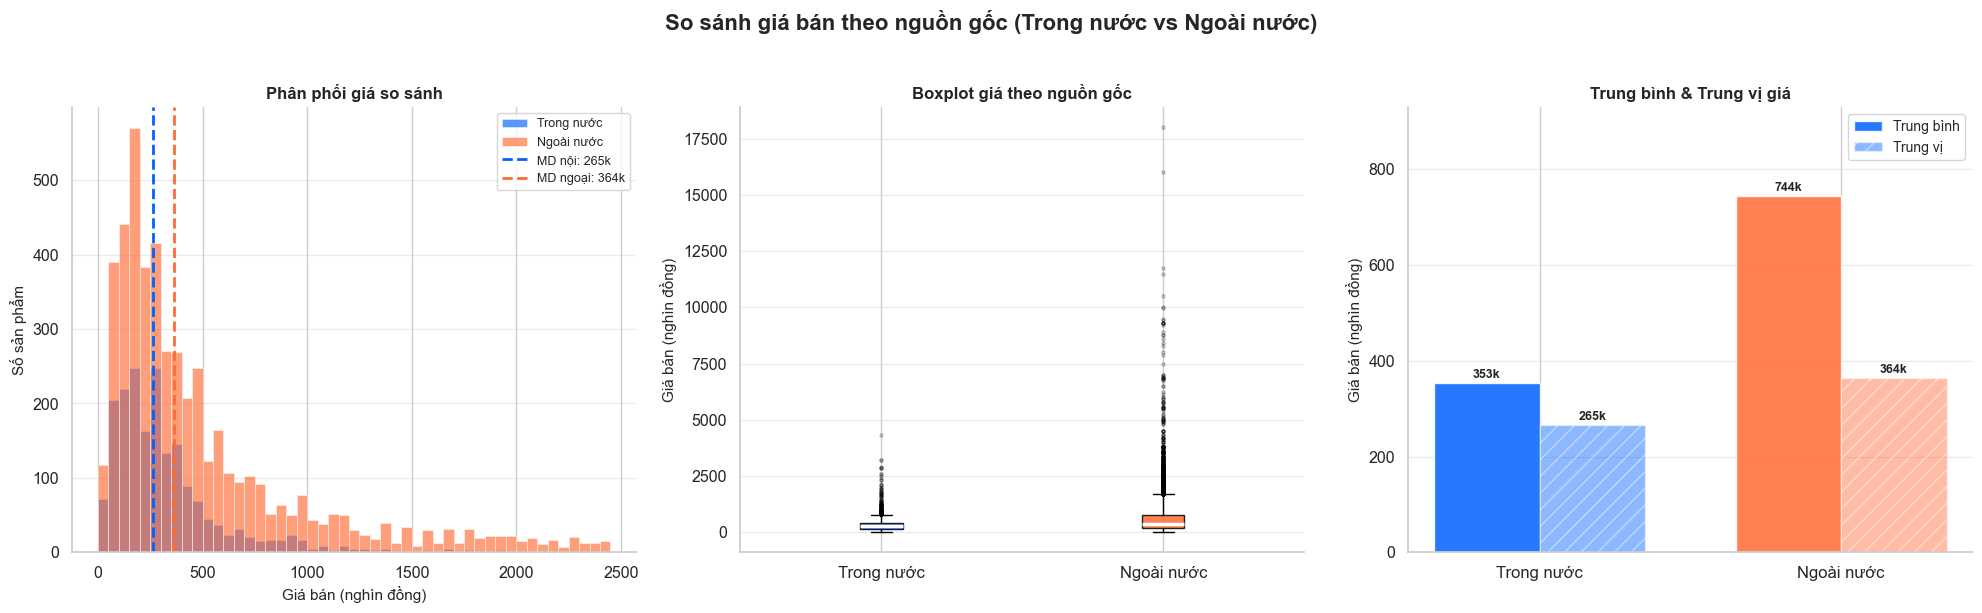

NHẬN XÉT SO SÁNH GIÁ:
  Trong nước → Trung bình: 353k | Trung vị: 265k
  Ngoài nước → Trung bình: 744k | Trung vị: 364k
  → Hàng ngoại có giá trung vị cao hơn hàng nội 1.4 lần.


In [42]:

# 3.1 SO SÁNH GIÁ THEO NGUỒN GỐC

price_k = df['price'] / 1000
dom_prices = price_k[df['origin_group'] == 'Trong nước']
for_prices = price_k[df['origin_group'] == 'Ngoài nước']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('So sánh giá bán theo nguồn gốc (Trong nước vs Ngoài nước)',
             fontsize=16, fontweight='bold', y=1.02)

# --- Histogram chồng ---
ax1 = axes[0]
p95 = price_k.quantile(0.95)
bins = np.linspace(0, p95, 50)
ax1.hist(dom_prices[dom_prices <= p95], bins=bins, alpha=0.65,
         color=COLOR_DOMESTIC, label='Trong nước', edgecolor='white', linewidth=0.5)
ax1.hist(for_prices[for_prices <= p95], bins=bins, alpha=0.65,
         color=COLOR_FOREIGN, label='Ngoài nước', edgecolor='white', linewidth=0.5)
ax1.axvline(dom_prices.median(), color=COLOR_DOMESTIC, lw=2, linestyle='--',
            label=f'MD nội: {dom_prices.median():,.0f}k')
ax1.axvline(for_prices.median(), color=COLOR_FOREIGN, lw=2, linestyle='--',
            label=f'MD ngoại: {for_prices.median():,.0f}k')
ax1.set_xlabel('Giá bán (nghìn đồng)', fontsize=11)
ax1.set_ylabel('Số sản phẩm', fontsize=11)
ax1.set_title('Phân phối giá so sánh', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.4)

# --- Boxplot ---
ax2 = axes[1]
data_box = [dom_prices.values, for_prices.values]
bp = ax2.boxplot(data_box, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2.5),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], PALETTE_MAIN):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Trong nước', 'Ngoài nước'], fontsize=12)
ax2.set_ylabel('Giá bán (nghìn đồng)', fontsize=11)
ax2.set_title('Boxplot giá theo nguồn gốc', fontsize=12, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.4)

# --- Bar chart trung bình & trung vị ---
ax3 = axes[2]
stats_dict = {
    'Trong nước': {'mean': dom_prices.mean(), 'median': dom_prices.median()},
    'Ngoài nước': {'mean': for_prices.mean(), 'median': for_prices.median()},
}
x = np.arange(2)
w = 0.35
means  = [stats_dict[g]['mean']   for g in ['Trong nước', 'Ngoài nước']]
medians = [stats_dict[g]['median'] for g in ['Trong nước', 'Ngoài nước']]
bars1 = ax3.bar(x - w/2, means, w, label='Trung bình', color=PALETTE_MAIN, alpha=0.85, edgecolor='white')
bars2 = ax3.bar(x + w/2, medians, w, label='Trung vị', color=PALETTE_MAIN, alpha=0.45, edgecolor='white', hatch='//')
for bar, val in zip(list(bars1) + list(bars2), means + medians):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'{val:,.0f}k', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['Trong nước', 'Ngoài nước'], fontsize=12)
ax3.set_ylabel('Giá bán (nghìn đồng)', fontsize=11)
ax3.set_title('Trung bình & Trung vị giá', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.set_ylim(0, max(means) * 1.25)
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_3_1_price_by_origin.png', dpi=150, bbox_inches='tight')
plt.show()

print('NHẬN XÉT SO SÁNH GIÁ:')
print(f'  Trong nước → Trung bình: {dom_prices.mean():,.0f}k | Trung vị: {dom_prices.median():,.0f}k')
print(f'  Ngoài nước → Trung bình: {for_prices.mean():,.0f}k | Trung vị: {for_prices.median():,.0f}k')
ratio = for_prices.median() / dom_prices.median()
print(f'  → Hàng ngoại có giá trung vị cao hơn hàng nội {ratio:.1f} lần.')

### **3.2. Nguồn gốc vs nhóm ngành hàng**

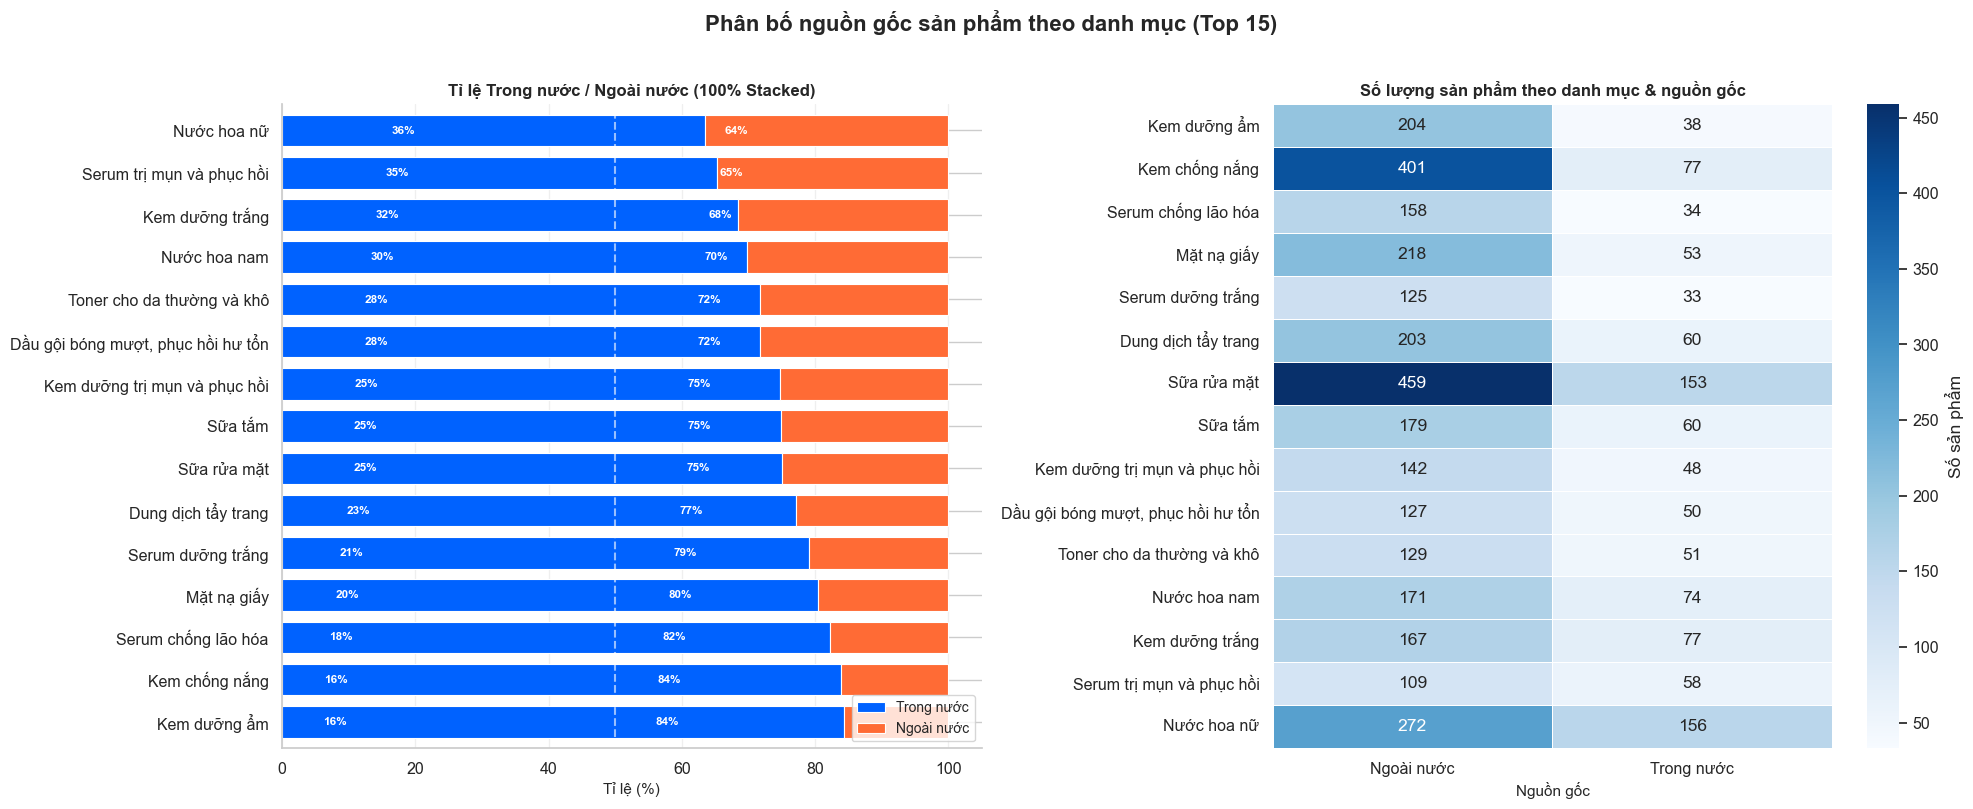

NHẬN XÉT:
  • Danh mục có tỉ lệ hàng nội cao nhất: Nước hoa nữ (36.4%)
  • Danh mục có tỉ lệ hàng ngoại cao nhất: Kem dưỡng ẩm (84.3%)


In [43]:

# 3.2 NGUỒN GỐC vs NHÓM NGÀNH HÀNG


top15_cats = df['primary_category'].value_counts().head(15).index
df_top = df[df['primary_category'].isin(top15_cats)].copy()

# --- Stacked bar ---
ct = pd.crosstab(df_top['primary_category'], df_top['origin_group'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct_sorted = ct_pct.sort_values('Trong nước', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Phân bố nguồn gốc sản phẩm theo danh mục (Top 15)',
             fontsize=16, fontweight='bold', y=1.01)

# --- Stacked 100% ---
ax1 = axes[0]
ct_pct_sorted.plot(kind='barh', stacked=True, ax=ax1,
                   color=[COLOR_DOMESTIC, COLOR_FOREIGN],
                   edgecolor='white', linewidth=0.8, width=0.75)
ax1.set_xlabel('Tỉ lệ (%)', fontsize=11)
ax1.set_ylabel('')
ax1.set_xlim(0, 105)
ax1.set_title('Tỉ lệ Trong nước / Ngoài nước (100% Stacked)', fontsize=12, fontweight='bold')
ax1.legend(['Trong nước', 'Ngoài nước'], loc='lower right', fontsize=10)
ax1.axvline(50, color='white', lw=1.5, linestyle='--', alpha=0.6)
for i, (cat, row) in enumerate(ct_pct_sorted.iterrows()):
    dom = row.get('Trong nước', 0)
    if dom > 8:
        ax1.text(dom / 2, i, f'{dom:.0f}%', ha='center', va='center',
                 fontsize=8.5, color='white', fontweight='bold')
    for_val = row.get('Ngoài nước', 0)
    if for_val > 8:
        ax1.text(dom + for_val / 2, i, f'{for_val:.0f}%',
                 ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='x', alpha=0.3)

# --- Absolute count heatmap ---
ax2 = axes[1]
ct_sorted = ct.loc[ct_pct_sorted.index]
sns.heatmap(ct_sorted, annot=True, fmt=',d', cmap='Blues',
            ax=ax2, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Số sản phẩm'})
ax2.set_title('Số lượng sản phẩm theo danh mục & nguồn gốc', fontsize=12, fontweight='bold')
ax2.set_xlabel('Nguồn gốc', fontsize=11)
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('plot_3_2_origin_vs_category.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Nhận xét ---
most_domestic = ct_pct['Trong nước'].idxmax() if 'Trong nước' in ct_pct.columns else 'N/A'
most_foreign  = ct_pct['Ngoài nước'].idxmax() if 'Ngoài nước' in ct_pct.columns else 'N/A'
dom_pct = ct_pct['Trong nước'].max() if 'Trong nước' in ct_pct.columns else 0
for_pct = ct_pct['Ngoài nước'].max() if 'Ngoài nước' in ct_pct.columns else 0
print('NHẬN XÉT:')
print(f'  • Danh mục có tỉ lệ hàng nội cao nhất: {most_domestic} ({dom_pct:.1f}%)')
print(f'  • Danh mục có tỉ lệ hàng ngoại cao nhất: {most_foreign} ({for_pct:.1f}%)')

### **3.3. Tỉ lệ hàng chính hãng theo nguồn gốc**

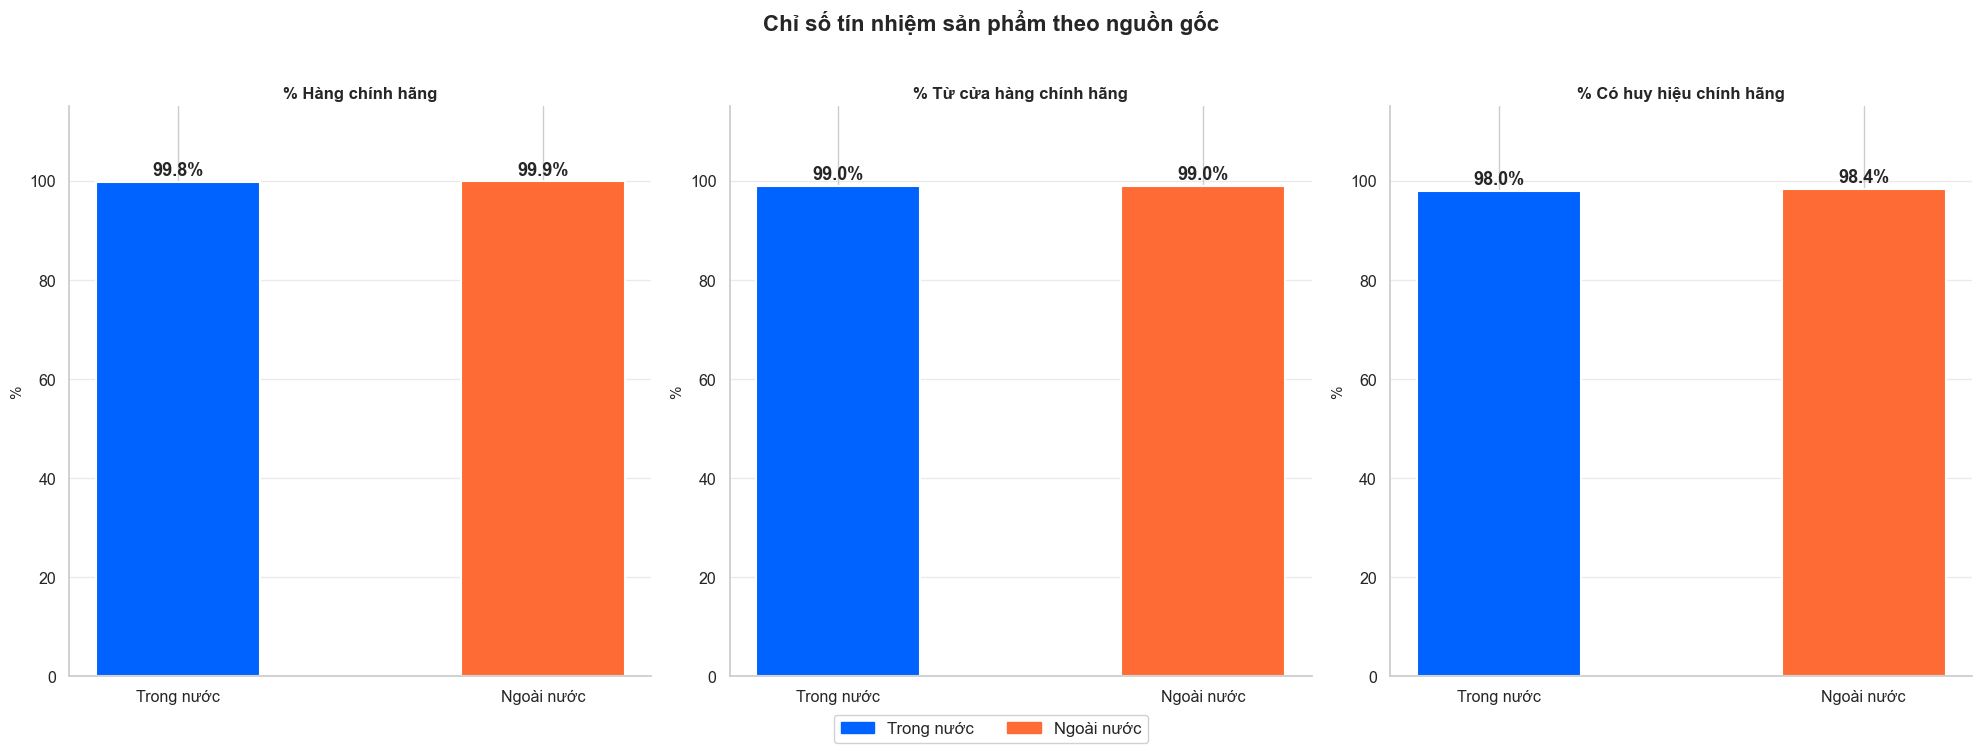

BẢNG TÓM TẮT CHỈ SỐ TÍN NHIỆM THEO NGUỒN GỐC
----------------------------------------------------------------------


Tiêu chí tín nhiệm,Ngoài nước,Trong nước
Chính_hãng,99.9%,99.8%
Cửa_hàng_chính_hãng,99.0%,99.0%
Có_huy_hiệu,98.4%,98.0%
Tiki_verified,66.8%,76.6%



NHẬN XÉT:
  • Trong nước: 99.8% hàng chính hãng, 99.0% từ cửa hàng chính hãng.
  • Ngoài nước: 99.9% hàng chính hãng, 99.0% từ cửa hàng chính hãng.


In [44]:
# 3.3 TỈ LỆ HÀNG CHÍNH HÃNG THEO NGUỒN GỐC

auth_map = {1: 'Chính hãng', 0: 'Không rõ / Không chính hãng'}
df['authentic_label'] = df['is_authentic'].map(auth_map)

# Theo nguồn gốc
auth_by_origin = df.groupby('origin_group')['is_authentic'].mean() * 100

# Official store
official_by_origin = df.groupby('origin_group')['is_official_store'].mean() * 100

# Authentic badge
badge_by_origin = df.groupby('origin_group')['has_authentic_badge'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Chỉ số tín nhiệm sản phẩm theo nguồn gốc',
             fontsize=16, fontweight='bold', y=1.02)

metrics = [
    (auth_by_origin,    '% Hàng chính hãng',        axes[0]),
    (official_by_origin,'% Từ cửa hàng chính hãng', axes[1]),
    (badge_by_origin,   '% Có huy hiệu chính hãng', axes[2]),
]
for series, title, ax in metrics:
    series = series.reindex(['Trong nước', 'Ngoài nước'])
    bars = ax.bar(series.index, series.values,
                  color=PALETTE_MAIN, edgecolor='white', linewidth=1.5, width=0.45)
    for bar, val in zip(bars, series.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 115)
    ax.set_ylabel('%', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.4)

# Thêm legend màu sắc
patch_dom = mpatches.Patch(color=COLOR_DOMESTIC, label='Trong nước')
patch_for = mpatches.Patch(color=COLOR_FOREIGN,  label='Ngoài nước')
fig.legend(handles=[patch_dom, patch_for], loc='lower center', ncol=2,
           fontsize=12, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

plt.tight_layout()
plt.savefig('plot_3_3_authentic_by_origin.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Bảng tóm tắt tín nhiệm ---
# Sử dụng đúng tên cột đã xác định trong data
col_origin = 'origin_class_corrected'

# Tính toán bảng tóm tắt
trust_summary = df.groupby(col_origin).agg(
    Chính_hãng=('is_authentic', lambda x: f"{x.mean()*100:.1f}%"),
    Cửa_hàng_chính_hãng=('is_official_store', lambda x: f"{x.mean()*100:.1f}%"),
    Có_huy_hiệu=('has_authentic_badge', lambda x: f"{x.mean()*100:.1f}%"),
    Tiki_verified=('tiki_verified', lambda x: f"{x.mean()*100:.1f}%"),
).T

# Đưa các chỉ số từ Index ra thành một cột riêng cho đẹp
trust_summary = trust_summary.reset_index()
trust_summary.rename(columns={'index': 'Tiêu chí tín nhiệm'}, inplace=True)

print('BẢNG TÓM TẮT CHỈ SỐ TÍN NHIỆM THEO NGUỒN GỐC')
print('-' * 70)

# Format giao diện Light Mode
styled_trust = (trust_summary.style
    .hide(axis="index")
    .set_properties(**{
        'background-color': '#ffffff',  
        'color': '#333333',             
        'border': '1px solid #e0e0e0',  
        'text-align': 'center',      
        'padding': '12px'
    })
    .set_table_styles([
        # Header xanh dương đậm chất chuyên nghiệp
        {'selector': 'th',
         'props': [('background-color', '#0062ff !important'), 
                   ('color', 'white !important'),
                   ('font-weight', 'bold !important'), 
                   ('text-align', 'center !important'),
                   ('border', '1px solid #e0e0e0 !important'),
                   ('padding', '12px !important')]},
        # Hiệu ứng hover dòng
        {'selector': 'tr:hover td',
         'props': [('background-color', '#f1f8ff !important')]}
    ])
)

display(styled_trust)

# Phần nhận xét tự động (đã sửa tên biến để không lỗi)
print('\nNHẬN XÉT:')
auth_vals = df.groupby(col_origin)['is_authentic'].mean() * 100
offi_vals = df.groupby(col_origin)['is_official_store'].mean() * 100

for group in ['Trong nước', 'Ngoài nước']:
    if group in auth_vals.index:
        print(f'  • {group}: {auth_vals[group]:.1f}% hàng chính hãng, '
              f'{offi_vals[group]:.1f}% từ cửa hàng chính hãng.')

In [47]:
# KẾT LUẬN PHÂN TÍCH EDA

print('KẾT LUẬN PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)')
print()
print('CẤU TRÚC DỮ LIỆU')
print(f'  • {df.shape[0]:,} sản phẩm mỹ phẩm, {df.shape[1]} đặc trưng')
print(f'  • {df["primary_category"].nunique()} danh mục sản phẩm')
print(f'  • {df["brand_name"].nunique():,} thương hiệu khác nhau')
print()
print('NGUỒN GỐC')
for g, cnt in df['origin_group'].value_counts().items():
    print(f'  • {g}: {cnt:,} SP ({cnt/len(df)*100:.1f}%)')
print()
print('GIÁ BÁN')
print(f'  • Trung vị: {(df["price"]/1000).median():,.0f}k VNĐ')
print(f'  • Phân khúc phổ biến: {df["price_segment"].value_counts().idxmax()}')
print()
print('LƯỢT BÁN & ĐÁNH GIÁ')
print(f'  • {(df["sold_count"] == 0).mean()*100:.1f}% sản phẩm chưa có lượt bán')
print(f'  • Rating trung bình (SP có rating): {df[df["rating"]>0]["rating"].mean():.2f}/5')
print()
print('CHÍNH HÃNG')
print(f'  • {df["is_authentic"].mean()*100:.1f}% sản phẩm được xác nhận chính hãng')
print(f'  • {df["is_official_store"].mean()*100:.1f}% từ cửa hàng chính hãng')

KẾT LUẬN PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

CẤU TRÚC DỮ LIỆU
  • 7,179 sản phẩm mỹ phẩm, 38 đặc trưng
  • 110 danh mục sản phẩm
  • 956 thương hiệu khác nhau

NGUỒN GỐC
  • Ngoài nước: 5,264 SP (73.3%)
  • Trong nước: 1,915 SP (26.7%)

GIÁ BÁN
  • Trung vị: 319k VNĐ
  • Phân khúc phổ biến: 100k – 300k

LƯỢT BÁN & ĐÁNH GIÁ
  • 41.9% sản phẩm chưa có lượt bán
  • Rating trung bình (SP có rating): 4.64/5

CHÍNH HÃNG
  • 99.9% sản phẩm được xác nhận chính hãng
  • 99.0% từ cửa hàng chính hãng
